In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Advertising.csv")
df.head()


,TV,Radio,Newspaper,Region,Market_Type,Season,Customer_Segment,Campaign_Type,Discount_Percent,Ad_Frequency,Ad_Keyword,Feedback_Tag,Sales
0,164890,19886,59750,North,Urban,Festival,Premium,Discount,20,6,Discount,Positive,20165
1,189621,14578,39544,North,Rural,Normal,Mass,Discount,5,13,Combo,Happy,9919
2,231284,48374,59993,North,Urban,Festival,Mass,Branding,15,5,Luxury,Positive,16896
3,160866,46717,31688,North,Rural,Festival,Premium,Discount,20,14,Discount,Happy,17102
4,242269,23497,73066,West,Semi-Urban,Normal,Premium,Branding,10,6,Launch,Satisfied,11817


In [3]:
df.shape


(600, 13)

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   TV                600 non-null    int64
 1   Radio             600 non-null    int64
 2   Newspaper         600 non-null    int64
 3   Region            600 non-null    str  
 4   Market_Type       600 non-null    str  
 5   Season            600 non-null    str  
 6   Customer_Segment  600 non-null    str  
 7   Campaign_Type     600 non-null    str  
 8   Discount_Percent  600 non-null    int64
 9   Ad_Frequency      600 non-null    int64
 10  Ad_Keyword        600 non-null    str  
 11  Feedback_Tag      600 non-null    str  
 12  Sales             600 non-null    int64
dtypes: int64(6), str(7)
memory usage: 88.2 KB


In [5]:
#Verifying the null values
df.isnull().sum()

TV                  0
Radio               0
Newspaper           0
Region              0
Market_Type         0
Season              0
Customer_Segment    0
Campaign_Type       0
Discount_Percent    0
Ad_Frequency        0
Ad_Keyword          0
Feedback_Tag        0
Sales               0
dtype: int64

In [6]:
#statistical information of numeric values only
df.describe()


,TV,Radio,Newspaper,Discount_Percent,Ad_Frequency,Sales
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,199233.228333,30523.215000,40362.830000,14.791667,9.013333,14992.080000
std,68384.501747,11981.467171,18927.039109,9.882360,3.766980,3066.731301
min,80061.000000,10086.000000,8336.000000,0.000000,3.000000,7428.000000
25%,141030.250000,19907.750000,24158.250000,5.000000,6.000000,12823.000000
50%,195550.500000,31125.000000,39252.500000,15.000000,9.000000,14874.500000
75%,257517.750000,41136.000000,56814.750000,25.000000,12.000000,17104.750000
max,319996.000000,51853.000000,74975.000000,30.000000,15.000000,22948.000000


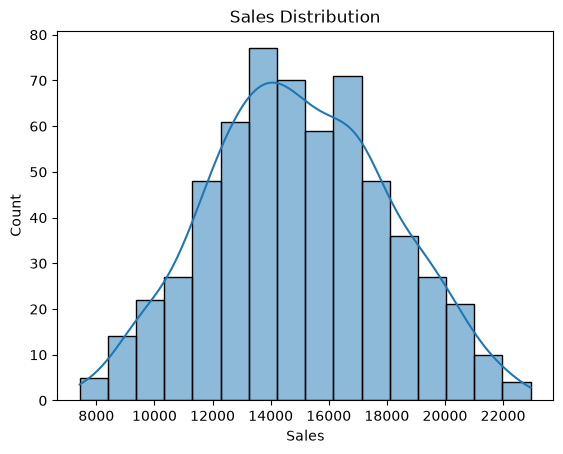

In [7]:
#Are the sales normally distributed
plt.figure()
sns.histplot(df["Sales"], kde=True)
plt.title("Sales Distribution")
plt.show()


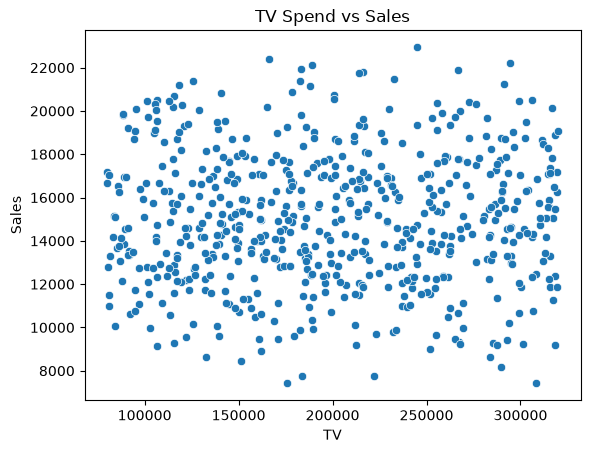

In [8]:
#correlation between TV and Sales
plt.figure()
sns.scatterplot(x=df["TV"], y=df["Sales"])
plt.title("TV Spend vs Sales")
plt.show()


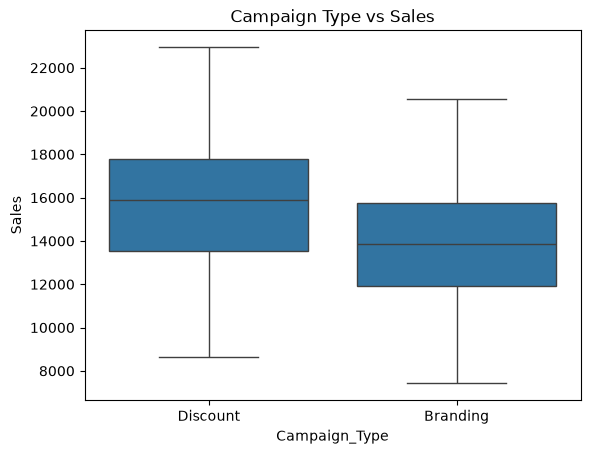

In [9]:
plt.figure()
sns.boxplot(x="Campaign_Type", y="Sales", data=df)
plt.title("Campaign Type vs Sales")
plt.show()


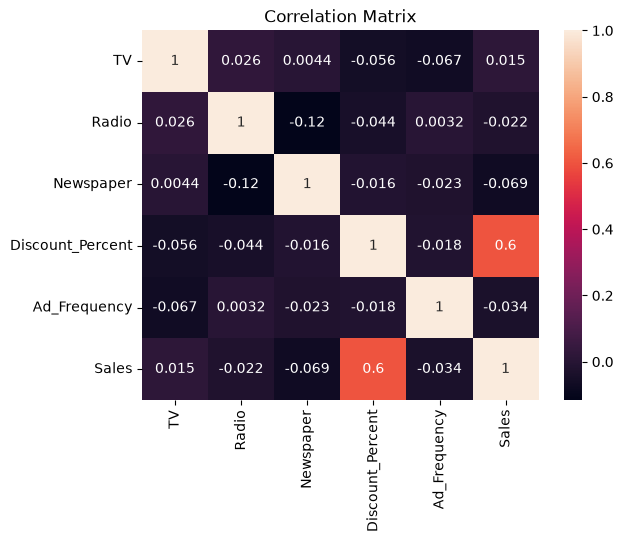

In [10]:
plt.figure()
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()


In [11]:
cat_cols = df.select_dtypes(include="str").columns
num_cols = df.select_dtypes(exclude="str").columns

print("Categorical Columns:")
print(cat_cols)

print("\nNumerical Columns:")
print(num_cols)



Categorical Columns:
Index(['Region', 'Market_Type', 'Season', 'Customer_Segment', 'Campaign_Type',
       'Ad_Keyword', 'Feedback_Tag'],
      dtype='str')

Numerical Columns:
Index(['TV', 'Radio', 'Newspaper', 'Discount_Percent', 'Ad_Frequency',
       'Sales'],
      dtype='str')


In [12]:
X_cat = df[cat_cols]
X_num = df[num_cols]
y = df["Sales"]

In [13]:
# Fit encoder
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown="ignore")
X_cat_encoded = encoder.fit_transform(X_cat)


In [14]:
import pickle
pickle.dump(encoder, open("encoder.pkl", "wb"))


In [15]:
X_num = df[num_cols]


In [16]:
X_num.drop("Sales", axis=1, inplace=True)

In [17]:
X_num.head()


,TV,Radio,Newspaper,Discount_Percent,Ad_Frequency
0,164890,19886,59750,20,6
1,189621,14578,39544,5,13
2,231284,48374,59993,15,5
3,160866,46717,31688,20,14
4,242269,23497,73066,10,6


In [18]:
y.head()

0    20165
1     9919
2    16896
3    17102
4    11817
Name: Sales, dtype: int64

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)
pickle.dump(scaler, open("scaler_knn.pkl", "wb"))


In [20]:
X_final = np.hstack((X_cat_encoded.toarray(), X_num_scaled))


In [21]:
X_final[0:5]


array([[ 0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  1.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         0.        , -0.5026268 , -0.88854648,  1.02516543,  0.52747312,
        -0.80060088],
       [ 0.        ,  1.        ,  0.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  0.        ,  1.        ,  1.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         0.        , -0.14067878, -1.33193365, -0.04329854, -0.99164946,
         1.05920205],
       [ 0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
       

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_final,   # encoded + numeric data 
    y,
    test_size=0.2,
    random_state=42
)


In [23]:
print("Training X shape:", X_train.shape)
print("Testing X shape:", X_test.shape)
print("Training y shape:", y_train.shape)
print("Testing y shape:", y_test.shape)


Training X shape: (480, 31)
Testing X shape: (120, 31)
Training y shape: (480,)
Testing y shape: (120,)


In [24]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(
    n_neighbors=7,
    weights="distance",
    metric="minkowski",
    algorithm="auto",
    n_jobs=-1,
    p=1
)
knn.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'distance'
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",1
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",-1
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'ma...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [25]:
y_pred = knn.predict(X_test)


c:\Users\Asus\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Asus\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\Asus\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Asus\AppData\Local\Programs\Python\Python314

In [26]:
#Evaluation metrics for Regression
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


MAE: 1664.0263224148644
RMSE: 2014.2349229751298


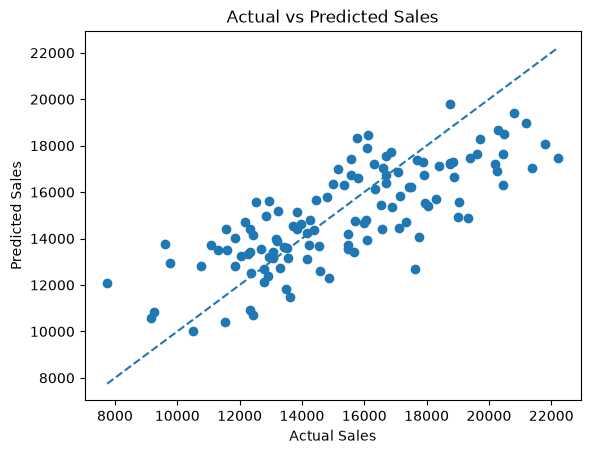

In [27]:
plt.figure()
plt.scatter(y_test, y_pred)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")
''' 
Starts at (min actual, min actual)
Ends at (max actual, max actual)
Equation: Predicted = Actual
This line shows perfect prediction.
'''

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()


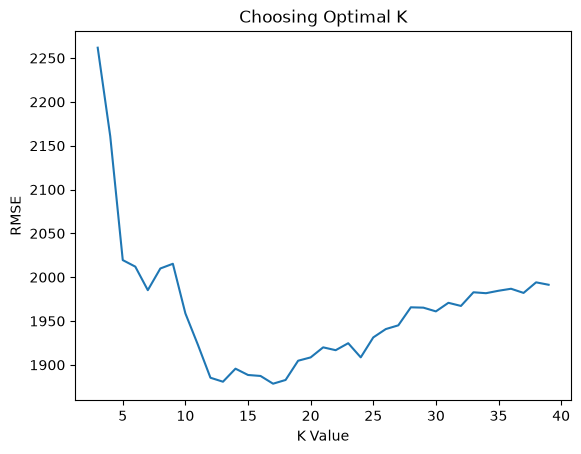

In [28]:
errors = []

for k in range(3, 40):
    knn = KNeighborsRegressor(n_neighbors=k)
    
    knn.fit(X_train, y_train)
    
    y_pred = knn.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    errors.append(rmse)

plt.figure()
plt.plot(range(3, 40), errors)
plt.xlabel("K Value")
plt.ylabel("RMSE")
plt.title("Choosing Optimal K")
plt.show()


In [29]:
with open("knn_sales_model.pkl", "wb") as f:
    pickle.dump(knn, f)

In [30]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_neighbors": list(range(12, 50)),
    "weights": ["uniform", "distance"],
    'p' : [1, 2],
    "algorithm": ["auto", "ball_tree"]

}



In [31]:
grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5
)

In [32]:
grid.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsReg..._neighbors=39)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'algorithm': ['auto', 'ball_tree'], 'n_neighbors': [12, 13, ...], 'p': [1, 2], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable ad

In [33]:
best_knn = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best RMSE:", -grid.best_score_)
#“Manual tuning checks few values.
#GridSearchCV checks all logical combinations and guarantees the best one.”

Best Parameters: {'algorithm': 'auto', 'n_neighbors': 12, 'p': 2, 'weights': 'distance'}
Best RMSE: 1817.102139196005


In [37]:
knn = KNeighborsRegressor(
    n_neighbors=12,
    weights="distance",
    algorithm="auto",
    p=2
)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",12
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [38]:
y_pred = best_knn.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test RMSE:", rmse)


Test RMSE: 1884.708627613162


In [36]:
with open("knn_sales_model.pkl", "wb") as f:
    pickle.dump(knn, f)